### This notebook performs classification of the participants into recovering or persistent. Classification labels are the classes labels at visit 4 (after one year) while the input data can come from different visits. The visit chosen as input can be specified in the running block as "visit_". 

+ The first section of this notebook imports libraries and data, combined atlas, modules, etc. This is a required step for the classification task. 
+ Second section performs classification both using SVMs and GBMs, both in the case of early prediction (visit 1 predicting visit 4) and all visits predicting visit 4 (visit 1,2,3 predicting visit 4).
+ Third section performs a permutation test for statistical validation of the results.
+ Fourth section performs analysis in which the former steps are performed in the case of visit 2 predicting visit 4 and visit 3 predicting visit 4.

All results are stored in CSV files at every step (before and after permutation). The output path will be created upon running the block, and the output will indicate the location of the file.

Import libraries

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
# import os
# from Carl_Response_Functions.load_responses import *
import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA, FastICA
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score


from nilearn import plotting
from nilearn import image
from nilearn import masking
from nilearn.image import concat_imgs
from sklearn.preprocessing import LabelEncoder
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.input_data import NiftiLabelsMasker
from nilearn.datasets import fetch_atlas_harvard_oxford
from nilearn.decoding import FREMClassifier

from nilearn.decoding import Decoder
from sklearn.model_selection import LeaveOneGroupOut
from nilearn.plotting import plot_stat_map, show
from nilearn.plotting import view_img
from nilearn.maskers import NiftiMasker

from nilearn.decoding import SearchLight
from sklearn.preprocessing import StandardScaler


from nilearn.glm import threshold_stats_img

from parcellation_to_classification_utils import *
from classification_functions import *

import numpy as np
import nibabel as nib
from nilearn.input_data import NiftiLabelsMasker
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
import os
import subprocess
import matplotlib.pyplot as plt
from nilearn import plotting
from matplotlib.colors import ListedColormap

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from nilearn import plotting
import nibabel as nib
import seaborn as sns
import numpy as np

#Import classification models (SVM - Gradientboosting)
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

#Change name based on machine used, see "Running classification"
user = "gaia"

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/input_data/__init__.py:27: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  warnings.warn(message, FutureWarning)


Combine cortical and subcortical atlases

In [3]:
#Retrieve paths used for analysis, path is based on user 
base_path, tian_atlas_path, tian_label_path, z_map_path, second_level_glm_path, run_mapping = obtain_base_paths(user)

# Load the Schaefer atlas (assuming get_schaefer_parcellation is defined)
schaefer_img, schaefer_labels = get_schaefer_parcellation(n_rois=200)

# Load the Tian atlas (assuming get_tian_parcellation is defined)
tian_img, tian_labels = get_tian_parcellation(tian_atlas_path, tian_label_path)

# Combine the atlases (assuming combine_parcellations is defined)
combined_img, combined_labels = combine_parcellations(schaefer_img, tian_img, schaefer_labels, tian_labels)

In [5]:
#Select subjects for classification
S_all = select_subject_id_and_group_label(z_map_path, second_level_glm_path, run_map = run_mapping, range_selected=70)

### Prediction from onset data and data from all the sessions. Where from all the sessions, the variable visit_selection should be "all". If early prediction (onset, visit 1) visit selection should be set to "1_and_4". There's examples of them as follows. Both support vector machines and GBM are used as follows. 

*Please be mindful of runtime when running the following blocks. Details on runtime are in readme*

### SVM prediction all visits

In [ ]:
# Define your classifier
classifier = SVC(kernel='linear', probability=True, class_weight='balanced', random_state = 0)

#Classifier name for saving 
classifier_name = "SVC"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

no_early_prediction = "all"

# Run main function if script is executed
if __name__ == "__main__":
    main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
          tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = no_early_prediction,
          distribution = "Real")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/SVC/Real_data/SVC_reproduced_all_visits.json


### SVM early prediction

In [ ]:
# Define your classifier
classifier = SVC(kernel='linear', probability=True, class_weight='balanced', random_state = 0)

#Classifier name for saving 
classifier_name = "SVC"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

early_prediction = "1_and_4"

# Run main function if script is executed
if __name__ == "__main__":
    main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
    tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = early_prediction,
    distribution = "Real")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/SVC/Real_data/SVC_reproduced_early_prediction.json


### GBM prediction all visits

In [ ]:
# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"

# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

no_early_prediction = "all"

# Run main function if script is executed
if __name__ == "__main__":
            main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
          tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = no_early_prediction,
          distribution = "Real")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_reproduced_all_visits.json


### GBM early prediction

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"

# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

early_prediction = "1_and_4"

# Run main function if script is executed
if __name__ == "__main__":
    main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
    tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = early_prediction,
    distribution = "Real")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_reproduced_early_prediction.json


### Saving CSV files for FDR correction and visualisations of classification (NO FDR APPLIED YET): 

+ Manipulate output CSV files for future FDR correction analysis
+ plot ROIs that are associated to variability of reported pain, glass BOLD data and confusion matrices. 

*Please note that the display_top_ROIs_from_classifier and visualize_top_rois_from_performance_df functions must be run to ensure that the csv files are correctly saved for future fdr correction in next notebooks. Details on readme*


### PERFORMANCE OF ALGORITHMS: all visits case

#### GBM 

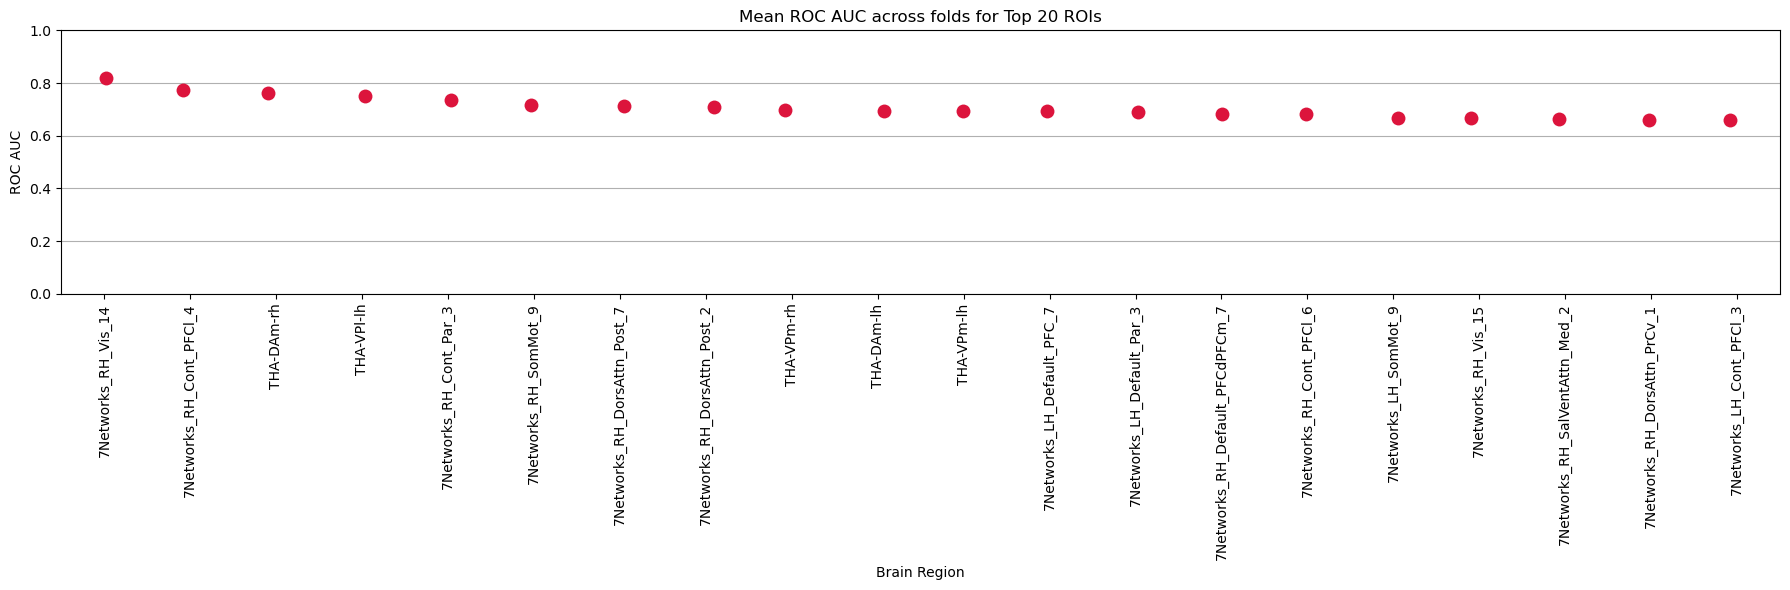

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


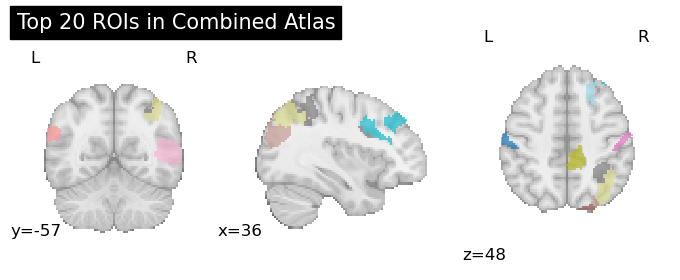

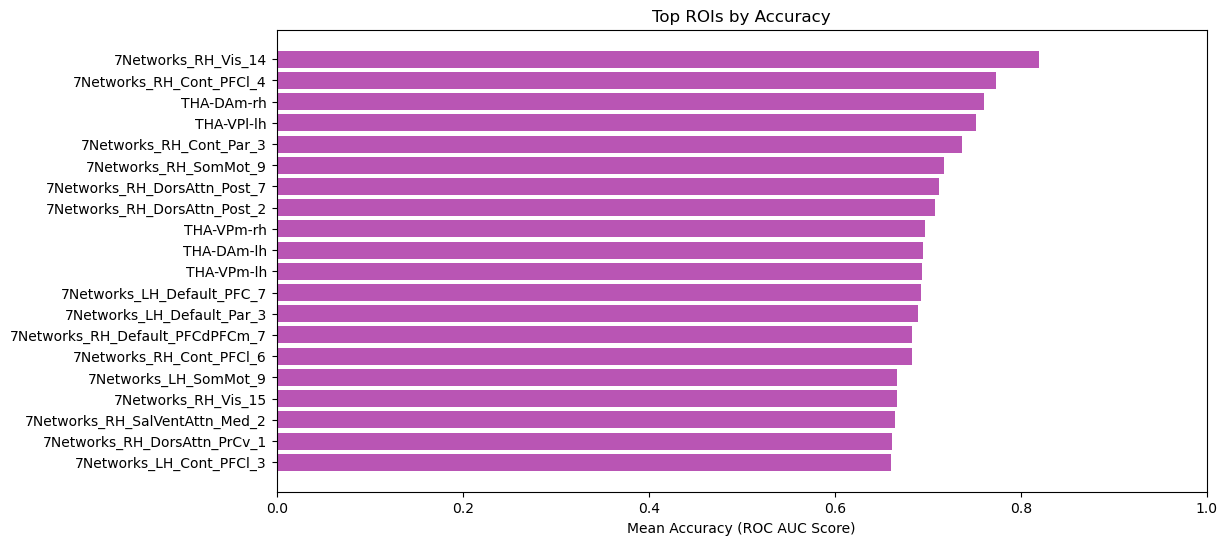

In [ ]:
#Path to GBM output
gbm_performance = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_reproduced_all_visits.json")

#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
gbm_setup_info, gbm_classifier_df, gbm_top_parcels = display_top_ROIs_from_classifier(gbm_performance, nr_top_parcels, setup=True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
visualize_top_rois_from_performance_df(gbm_classifier_df, base_path, combined_labels, combined_img,
                                        top_n=nr_top_parcels, model="GBM", save_nifti = False)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(gbm_top_parcels)

barplot_top_ROIs(gbm_classifier_df, nr_top_parcels, model_used="GBM")


#### SVC 

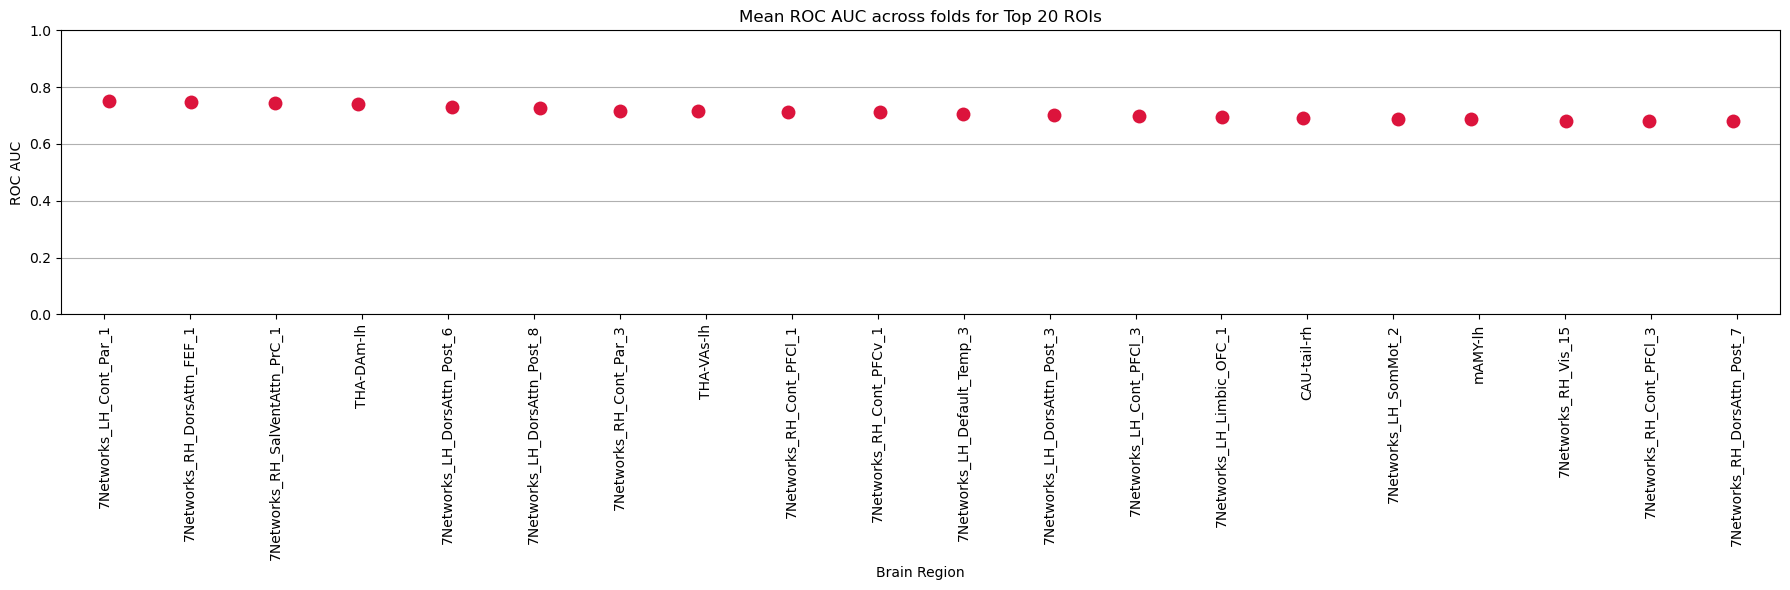

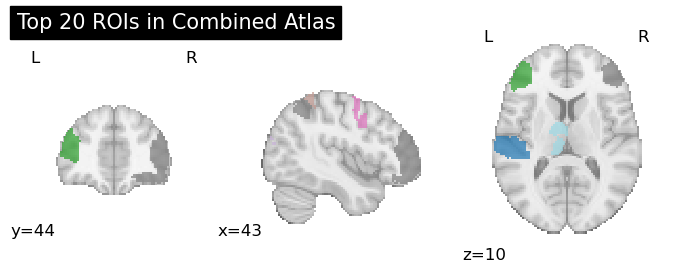

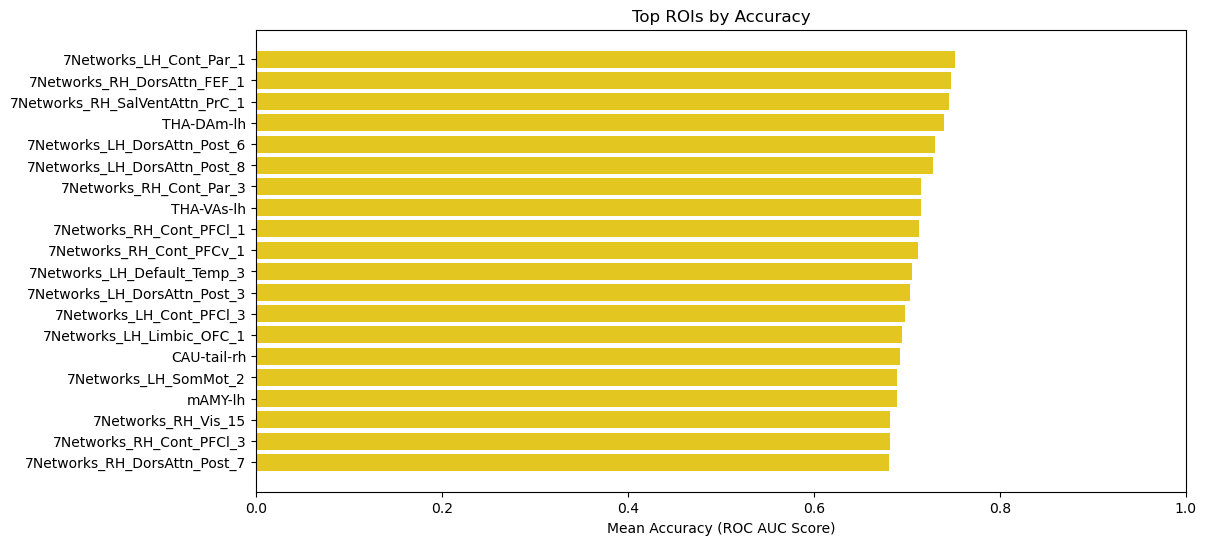

In [ ]:
#Path to SVM output
#svc_performance = pd.read_json("Results/fMRI_Classifiers_Output/SVC/Real_data/SVC_all_visits.json")
svc_performance = pd.read_json("Results/fMRI_Classifiers_Output/SVC/Real_data/SVC_reproduced_all_visits.json")

#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
svc_setup_info, svc_classifier_df, svc_top_parcels = display_top_ROIs_from_classifier(svc_performance, nr_top_parcels,setup=True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
visualize_top_rois_from_performance_df(svc_classifier_df, base_path, combined_labels, combined_img, model = "SVC", top_n=20,
                                       save_nifti = False)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(svc_top_parcels)

barplot_top_ROIs(svc_classifier_df, nr_top_parcels, model_used = "SVC")

### ALGORITHMS PERFORMANCE: Early prediction (visit 1 predicts visit 4)

#### GBM

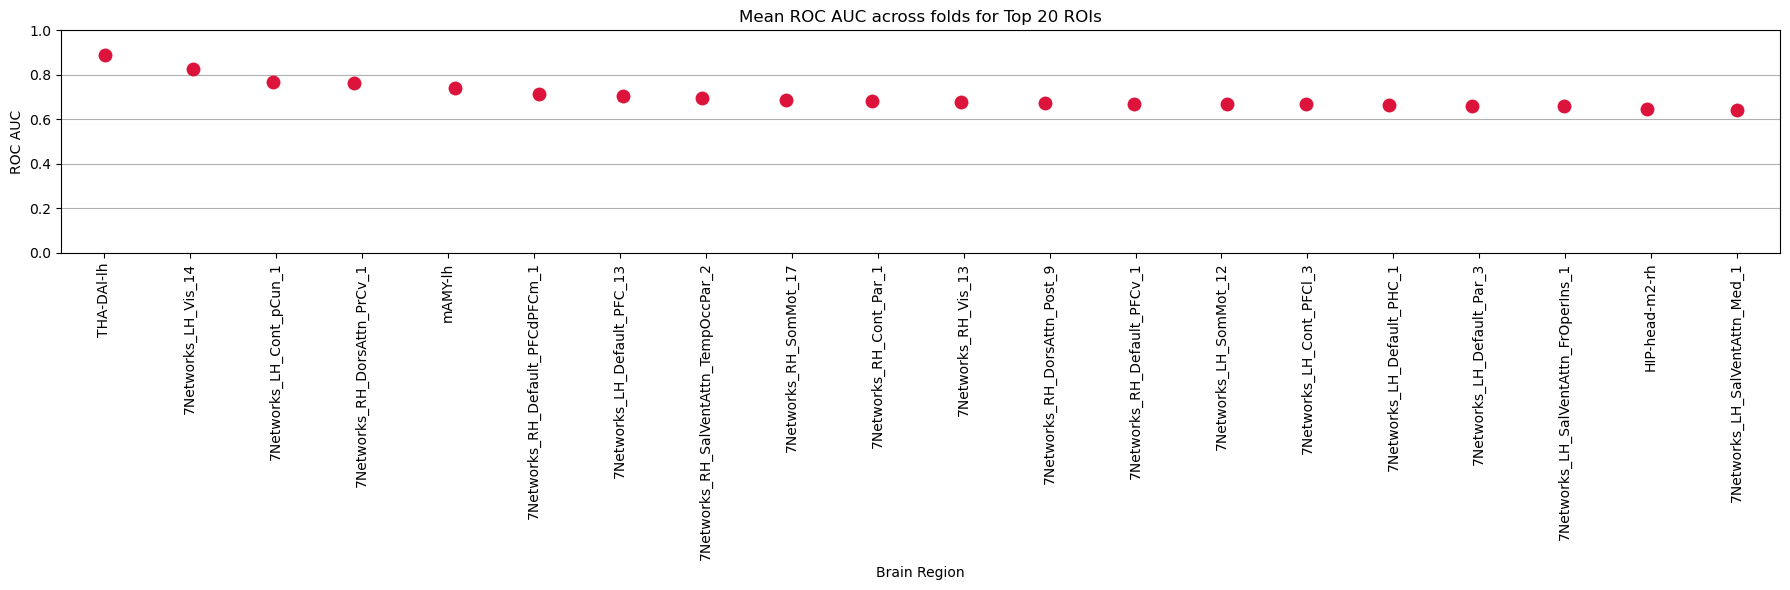

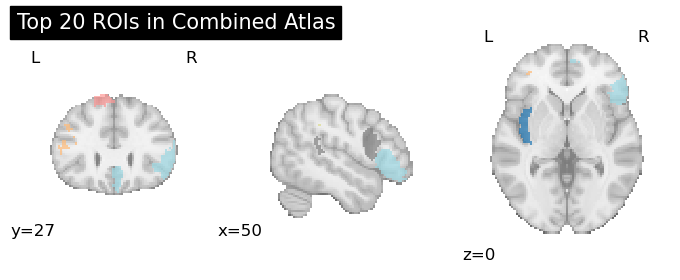

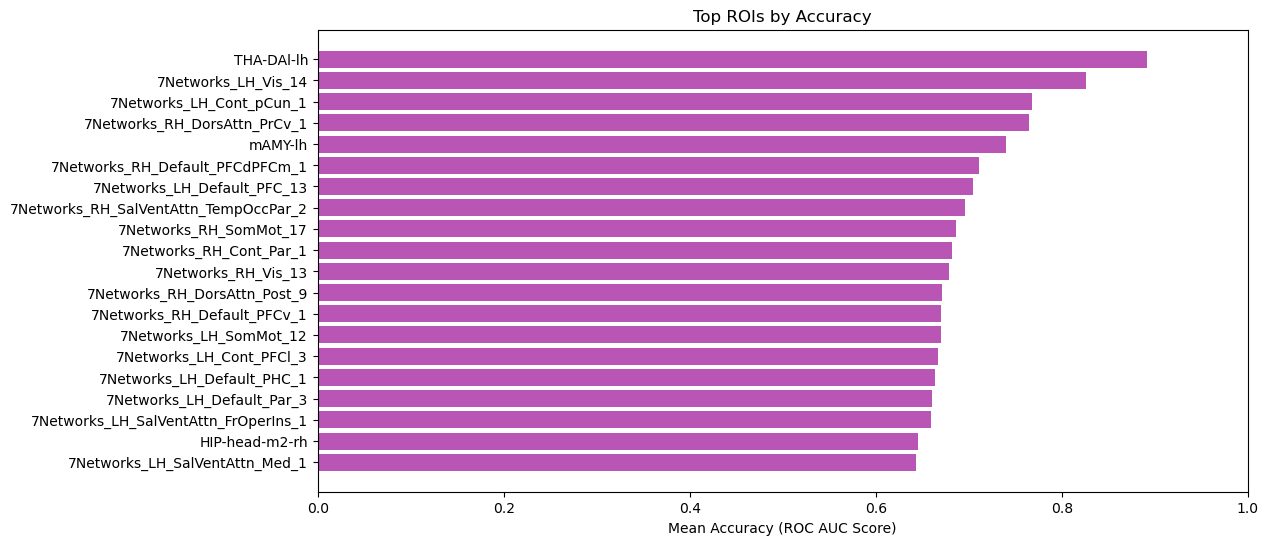

In [ ]:
#Path to GBM output
# gbm_early_performance = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_early_prediction.json")
gbm_early_performance = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_reproduced_early_prediction.json")


#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
gbm_early_setup_info, gbm_early_classifier_df, gbm_early_top_parcels = display_top_ROIs_from_classifier(gbm_early_performance, nr_top_parcels,
                                                                                                        setup=True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
visualize_top_rois_from_performance_df(gbm_early_classifier_df, base_path, combined_labels, combined_img, top_n=nr_top_parcels,
                                       model = "GBM_early_pred", save_nifti = False)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(gbm_early_top_parcels)

barplot_top_ROIs(gbm_early_classifier_df, nr_top_parcels, model_used="GBM")

#### SVC

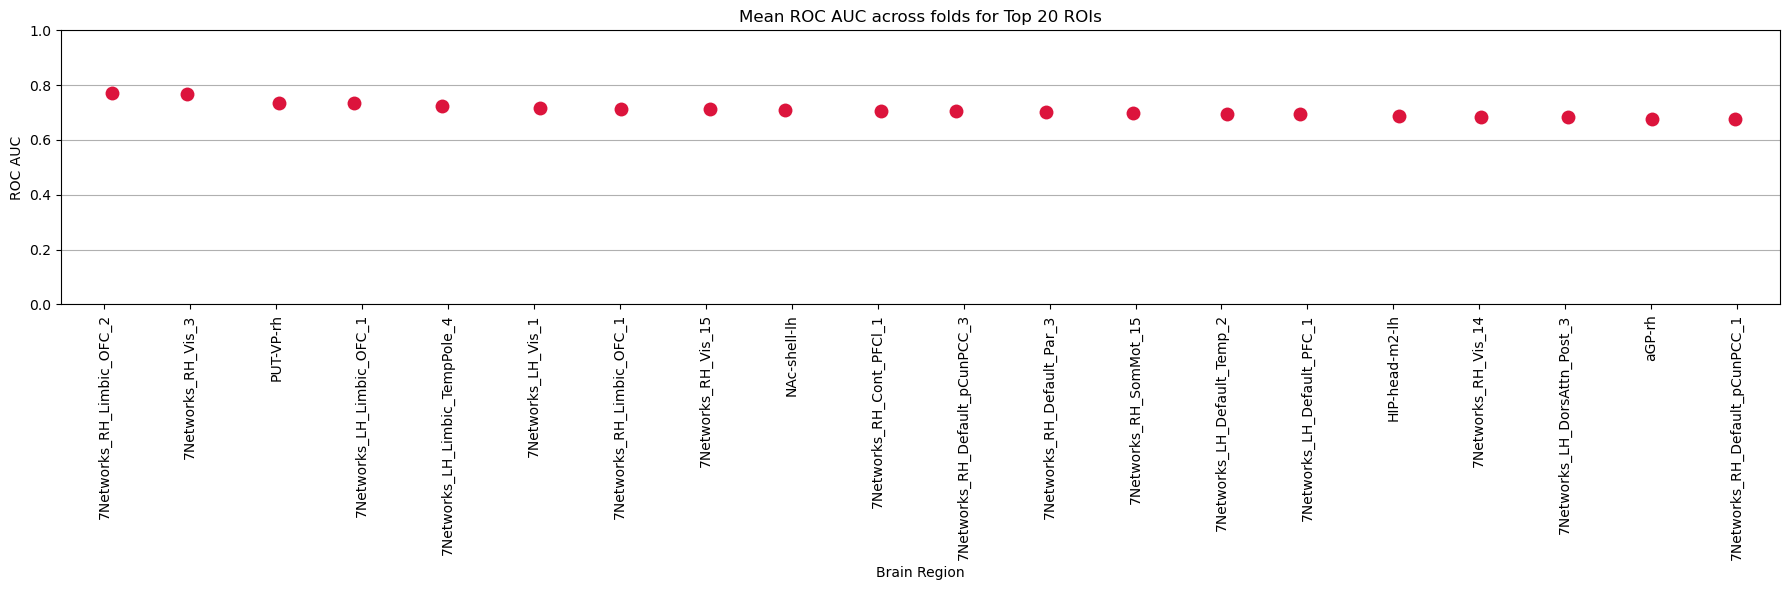

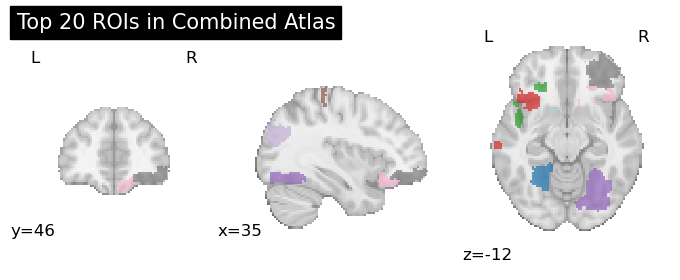

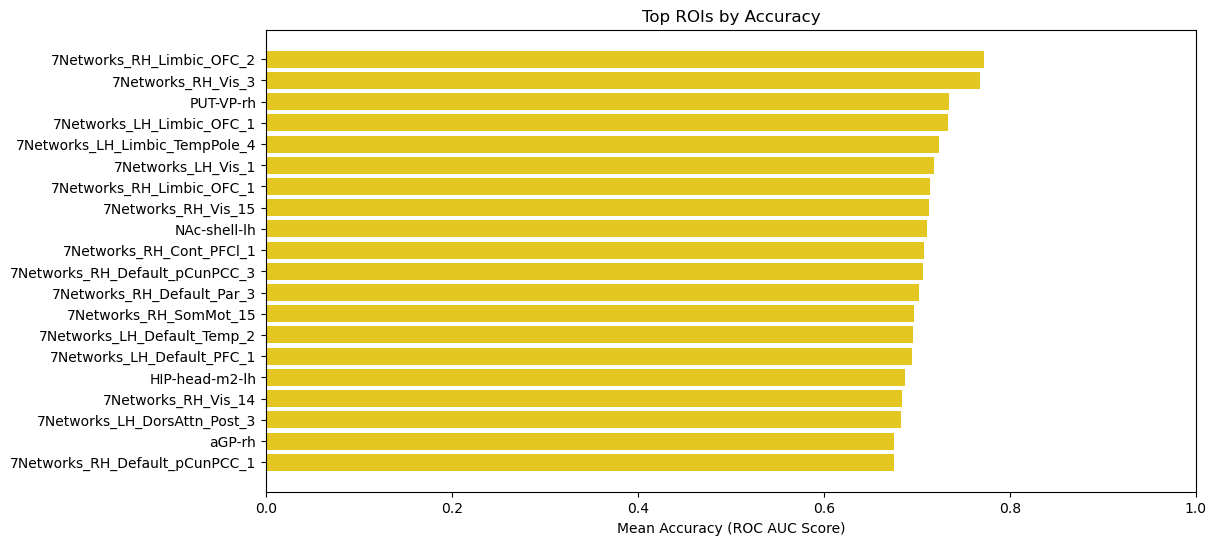

In [ ]:
#Path to SVM output
svc_early_performance = pd.read_json("Results/fMRI_Classifiers_Output/SVC/Real_data/SVC_reproduced_early_prediction.json")

#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
svc_early_setup_info, svc_early_classifier_df, svc_early_top_parcels = display_top_ROIs_from_classifier(svc_early_performance, nr_top_parcels,
                                                                                                        setup=True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
visualize_top_rois_from_performance_df(svc_early_classifier_df, base_path, combined_labels, combined_img, top_n=20,
                                       model = "SVC_early_pred", save_nifti = False)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(svc_early_top_parcels)

barplot_top_ROIs(svc_early_classifier_df, nr_top_parcels, model_used = "SVC")

# BASELINE TESTS

"Label_Shuffling"


### SVC all visits - null distribution

In [ ]:
# Define your classifier
classifier = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=0)

#Classifier name for saving 
classifier_name = "SVC"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

no_early_prediction = "all"

iteration_n = 1000

# Run main function if script is executed
if __name__ == "__main__":
    null_main(classifier,
                visit_range,
                classifier_name,
                z_map_path,
                run_mapping=run_mapping,
                iters=iteration_n,
                S_all = S_all,
                base_path = base_path,
                tian_atlas_path = tian_atlas_path,
                tian_label_path = tian_label_path,
                visit_selection=no_early_prediction)

Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Iteration 700
Iteration 710
Ite

### SVC visit 1 and 4 - null distribution

In [ ]:
# Define your classifier
classifier = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=0)

#Classifier name for saving 
classifier_name = "SVC"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

early_prediction = "1_and_4"

iteration_n =1000

# Run main function if script is executed
if __name__ == "__main__":
    null_main(classifier,
            visit_range,
            classifier_name,
            z_map_path,
            run_mapping=run_mapping,
            iters=iteration_n,
            S_all = S_all,
            base_path = base_path,
            tian_atlas_path = tian_atlas_path,
            tian_label_path = tian_label_path,
            visit_selection=early_prediction)

Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Iteration 700
Iteration 710
Ite

### GBM all visits - null distribution

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=0)

classifier_name = "GradientBoostingClassifier"

# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

no_early_prediction = "all"

iteration_n = 700

# Run main function if script is executed
if __name__ == "__main__":
    null_main(classifier,
        visit_range,
        classifier_name,
        z_map_path,
        run_mapping=run_mapping,
        iters=iteration_n,
        S_all = S_all,
        base_path = base_path,
        tian_atlas_path = tian_atlas_path,
        tian_label_path = tian_label_path,
        visit_selection=no_early_prediction)

Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Results saved to: base path/Res

### GBM 1 and 4 - null distribution

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"

# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

early_prediction = "1_and_4"

iteration_n = 700

# Run main function if script is executed
if __name__ == "__main__":
    null_main(classifier,
        visit_range,
        classifier_name,
        z_map_path,
        run_mapping=run_mapping,
        iters=iteration_n,
        S_all = S_all,
        base_path = base_path,
        tian_atlas_path = tian_atlas_path,
        tian_label_path = tian_label_path,
        visit_selection=early_prediction)

Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Results saved to: base path/Res

### Plot null performance to ensure the distribution is correct

#### Plot SVC null performance (all visits: visits 1,2,3 predict 4)

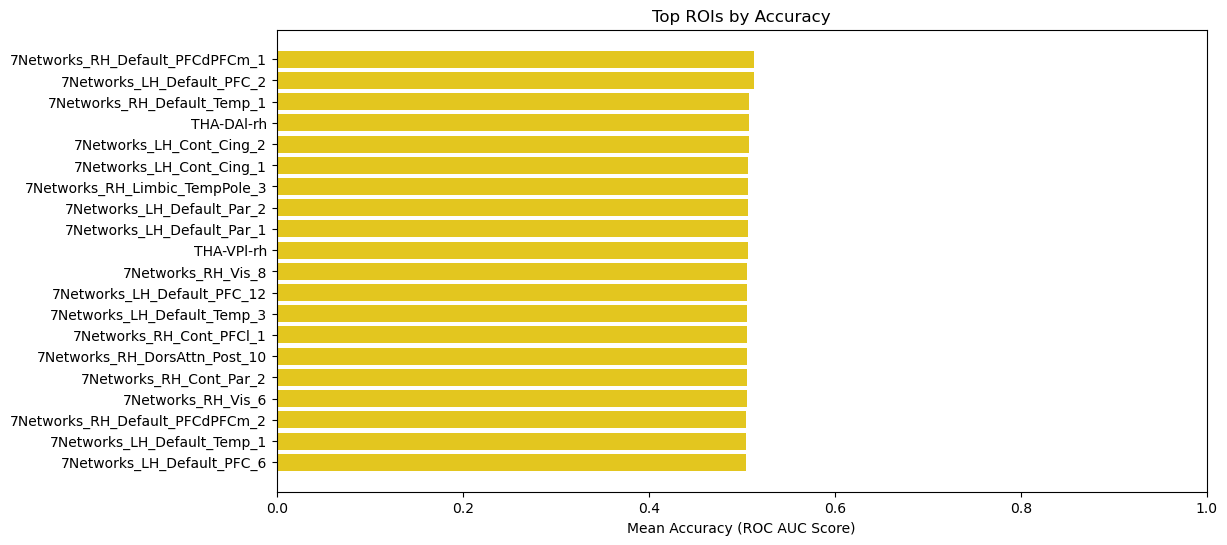

In [ ]:
# #Path to SVM output
svc_null_performance = pd.read_json("Results/fMRI_Classifiers_Output/SVC/Null_data/SVC_all_visits_null.json")

# #number of top parcels to consider
nr_top_parcels = 20

# #Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
svc_null_setup_info, svc_null_classifier_df, svc_null_top_parcels = display_top_ROIs_from_classifier(svc_null_performance, nr_top_parcels,
                                                                                                     setup=True)

# # --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
#visualize_top_rois_from_performance_df(svc_null_classifier_df, base_path, combined_labels, combined_img, top_n=20,model=SVC)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(svc_top_parcels)

barplot_top_ROIs(svc_null_classifier_df, nr_top_parcels, model_used = "SVC")

#### Plot SVM null performance (visit 1 predicts 4)

,setup_info,performance_stats,confusion_matrices
setup_style,default,NaN,NaN
date,2025-05-18_12-18-42,NaN,NaN
classifier,SVC,NaN,NaN
visit_range,"[1, 2, 3, 4]",NaN,NaN
7Networks_LH_Vis_1,NaN,"{'mean': 0.500581785714285, 'std': 0.189626182...","[[[1, 3], [0, 7]], [[1, 3], [2, 5]], [[1, 3], ..."
...,...,...,...
THA-DP-lh,NaN,"{'mean': 0.501007857142857, 'std': 0.191535720...","[[[3, 1], [2, 5]], [[3, 1], [2, 5]], [[2, 2], ..."
NAc-shell-lh,NaN,"{'mean': 0.49861083333333306, 'std': 0.1901899...","[[[2, 2], [4, 3]], [[1, 3], [4, 3]], [[3, 1], ..."
NAc-core-lh,NaN,"{'mean': 0.49682357142857103, 'std': 0.1927658...","[[[2, 2], [3, 4]], [[4, 0], [4, 3]], [[3, 1], ..."
pGP-lh,NaN,"{'mean': 0.49873595238095203, 'std': 0.1903944...","[[[1, 3], [0, 7]], [[0, 4], [0, 7]], [[0, 4], ..."


,brain_region,performance_stats,confusion_matrices,mean_performance
4,7Networks_LH_Vis_1,"{'mean': 0.500581785714285, 'std': 0.189626182...","[[[1, 3], [0, 7]], [[1, 3], [2, 5]], [[1, 3], ...",0.500582
5,7Networks_LH_Vis_2,"{'mean': 0.503839285714285, 'std': 0.188730317...","[[[1, 3], [3, 4]], [[0, 4], [3, 4]], [[1, 3], ...",0.503839
6,7Networks_LH_Vis_3,"{'mean': 0.49959547619047606, 'std': 0.1902734...","[[[0, 4], [4, 3]], [[1, 3], [4, 3]], [[0, 4], ...",0.499595
7,7Networks_LH_Vis_4,"{'mean': 0.496279404761904, 'std': 0.189445412...","[[[4, 0], [7, 0]], [[2, 2], [5, 2]], [[2, 2], ...",0.496279
8,7Networks_LH_Vis_5,"{'mean': 0.5009134523809521, 'std': 0.19003833...","[[[1, 3], [4, 3]], [[1, 3], [6, 1]], [[3, 1], ...",0.500913
...,...,...,...,...
253,THA-DP-lh,"{'mean': 0.501007857142857, 'std': 0.191535720...","[[[3, 1], [2, 5]], [[3, 1], [2, 5]], [[2, 2], ...",0.501008
254,NAc-shell-lh,"{'mean': 0.49861083333333306, 'std': 0.1901899...","[[[2, 2], [4, 3]], [[1, 3], [4, 3]], [[3, 1], ...",0.498611
255,NAc-core-lh,"{'mean': 0.49682357142857103, 'std': 0.1927658...","[[[2, 2], [3, 4]], [[4, 0], [4, 3]], [[3, 1], ...",0.496824
256,pGP-lh,"{'mean': 0.49873595238095203, 'std': 0.1903944...","[[[1, 3], [0, 7]], [[0, 4], [0, 7]], [[0, 4], ...",0.498736


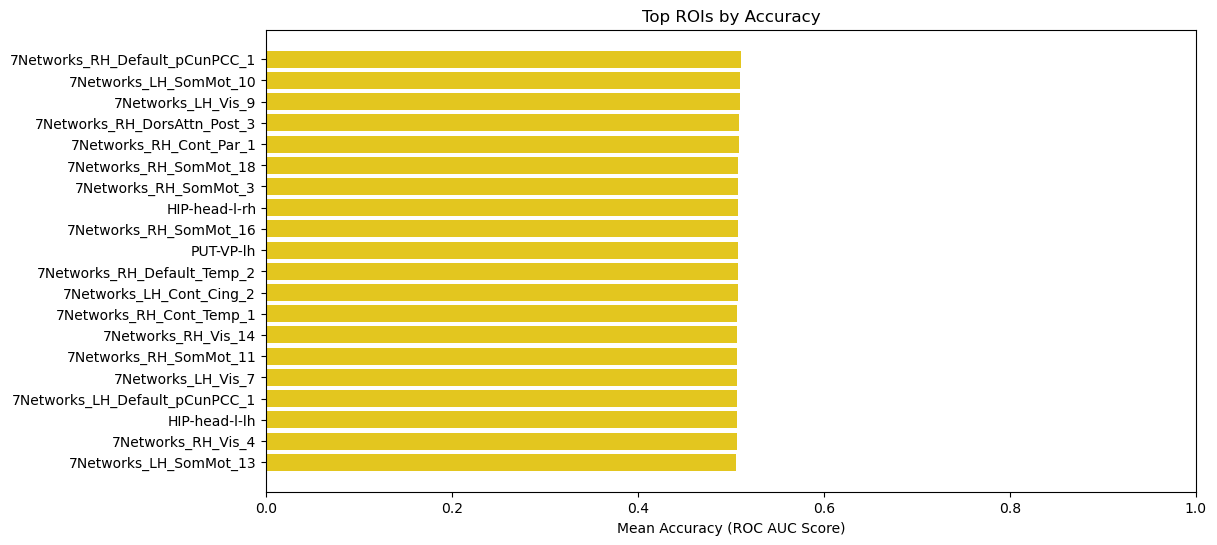

In [ ]:
#Path to SVM output
svc_null_early_performance = pd.read_json("Results/fMRI_Classifiers_Output/SVC/Null_data/SVC_early_prediction_null.json")

#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
svc_null_early_setup_info, svc_null_early_classifier_df, svc_null_early_top_parcels = display_top_ROIs_from_classifier(svc_null_early_performance, nr_top_parcels,
                                                                                                                       setup=True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
#visualize_top_rois_from_performance_df(svc_null_early_classifier_df, combined_labels, combined_img, top_n=20)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(svc_top_parcels)

barplot_top_ROIs(svc_null_early_classifier_df, nr_top_parcels, model_used = "SVC_early_performance")

### GBM visualisation null performance (all visits: visits 1,2,3 predict 4)

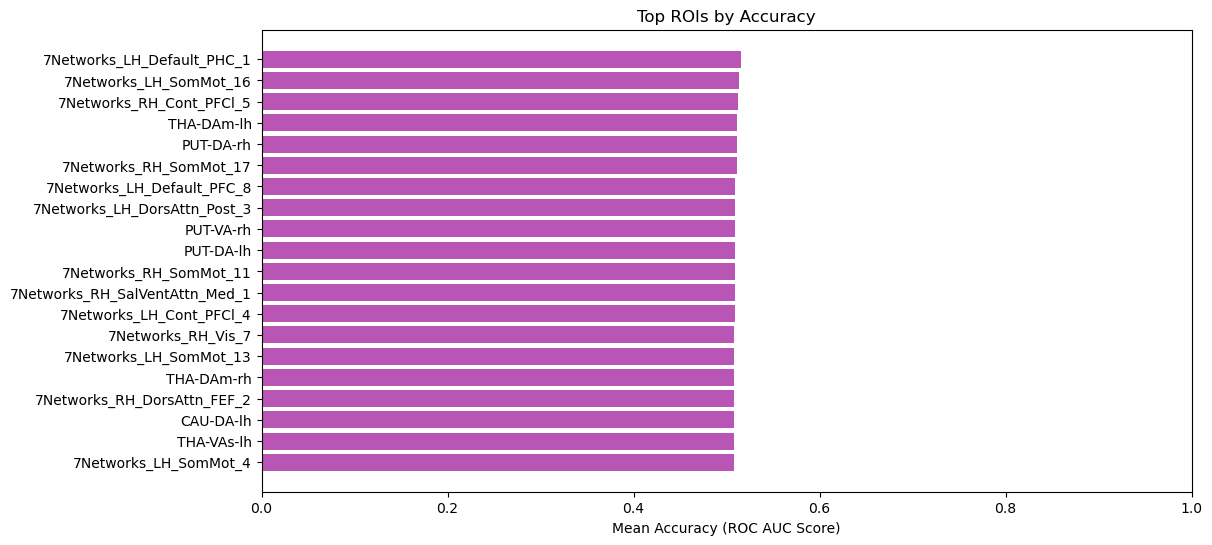

In [ ]:
#Path to SVM output
gbm_null_performance = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Null_data/GradientBoostingClassifier_all_visits_null.json")

#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
gbm_null_setup_info, gbm_null_classifier_df, gbm_null_top_parcels = display_top_ROIs_from_classifier(gbm_null_performance, nr_top_parcels,
                                                                                                     setup = True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
#visualize_top_rois_from_performance_df(gbm_null_classifier_df, combined_labels, combined_img, top_n=20)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(svc_top_parcels)

barplot_top_ROIs(gbm_null_classifier_df, nr_top_parcels, model_used = "GBM")

### GBM visualisation null performance (visit 1 predicts 4)

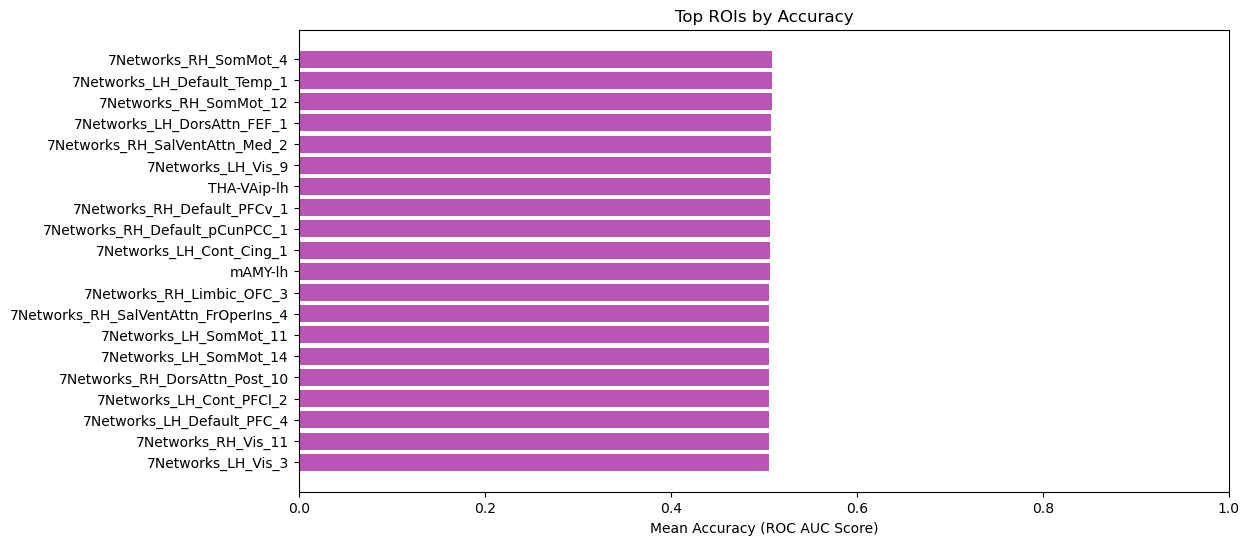

In [ ]:
#Path to SVM output
gbm_null_performance_early_pred = pd.read_json("Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Null_data/GradientBoostingClassifier_early_prediction_null.json")

#number of top parcels to consider
nr_top_parcels = 20

#Setup info of GBM, df of GBM output, nr_top_parcels parcels considered from GBM output
gbm_null_early_setup_info, gbm_null_early_classifier_df, gbm_null_early_top_parcels = display_top_ROIs_from_classifier(gbm_null_performance_early_pred, nr_top_parcels,
                                                                                                                       setup = True)

# --- Visualise violin plots of mean performance per iteration, top 20 combined atlas glass, and top5 glass brain
#visualize_top_rois_from_performance_df(gbm_null_early_classifier_df, combined_labels, combined_img, top_n=20)

# -- Display the average confusion matrix (across n iterations, each y folds) per top 20 parcels
#confusion_matrix_per_fold(svc_top_parcels)

barplot_top_ROIs(gbm_null_early_classifier_df, nr_top_parcels, model_used = "GBM")

# Permutation tests

### Permutation test GBM all visits 

In [ ]:
#Classifier name
classifier_name = "GradientBoostingClassifier"

#Obtain results of permutation test (empirical p-values)
gbm_permutatation_test_results = permutation_test(gbm_null_classifier_df, gbm_classifier_df)

#Pick number of parcels to study
nr_top_parcels = 20 

# Filter by those results that are below 0.05
significant_results = gbm_permutatation_test_results[gbm_permutatation_test_results["p_value"] < 0.05]

# Then sort and take top N (up to nr_top_parcels)
gbm_top_permutation = significant_results.sort_values(by="p_value", ascending=True).head(nr_top_parcels)

# Generate path to store the significant parcels df 
save_path = generate_output_significant_parcels(base_path, classifier_name, "fMRI")

#By default, the values are saved in Intermediate_Files under classifier_name dir
gbm_top_permutation.to_csv(os.path.join(save_path, "gbm_significant_parcels_df"), index=False)


### Permutation test SVM all visits 

In [ ]:
#Classifier name
classifier_name = "SVC"

#Obtain results of permutation test (empirical p-values)
svc_permutatation_test_results = permutation_test(svc_null_classifier_df, svc_classifier_df)

#Pick number of parcels to study
nr_top_parcels = 20 

# Filter by those results that are below 0.05
significant_results = svc_permutatation_test_results[svc_permutatation_test_results["p_value"] < 0.05]

# Then sort and take top N (up to nr_top_parcels)
svc_top_permutation = significant_results.sort_values(by="p_value", ascending=True).head(nr_top_parcels)

# Generate path to store the significant parcels df 
save_path = generate_output_significant_parcels(base_path, classifier_name, "fMRI")

#By default, the values are saved in Intermediate_Files under classifier_name dir
svc_top_permutation.to_csv(os.path.join(save_path, "svc_significant_parcels_df"), index=False)

### Permutation test GBM early prediction

In [ ]:
#Classifier name
classifier_name = "GradientBoostingClassifier"

#Obtain results of permutation test (empirical p-values)
gbm_permutatation_test_results = permutation_test(gbm_null_early_classifier_df, gbm_early_classifier_df)

#Pick number of parcels to study
nr_top_parcels = 20 

# Filter by those results that are below 0.05
significant_results = gbm_permutatation_test_results[gbm_permutatation_test_results["p_value"] < 0.05]

# Then sort and take top N (up to nr_top_parcels)
gbm_top_permutation = significant_results.sort_values(by="p_value", ascending=True).head(nr_top_parcels)

# Generate path to store the significant parcels df 
save_path = generate_output_significant_parcels(base_path, classifier_name, "fMRI")

#By default, the values are saved in Intermediate_Files under classifier_name dir
gbm_top_permutation.to_csv(os.path.join(save_path, "early_prediction_gbm_significant_parcels_df"), index=False)

### Permutation test SVM early prediction

In [ ]:
#Classifier name
classifier_name = "SVC"

#Obtain results of permutation test (empirical p-values)
svc_permutatation_test_results = permutation_test(svc_null_early_classifier_df, svc_early_classifier_df)

#Pick number of parcels to study
nr_top_parcels = 20 

# Filter by those results that are below 0.05
significant_results = svc_permutatation_test_results[svc_permutatation_test_results["p_value"] < 0.05]

# Then sort and take top N (up to nr_top_parcels)
svc_top_permutation = significant_results.sort_values(by="p_value", ascending=True).head(nr_top_parcels)

# Generate path to store the significant parcels df 
save_path = generate_output_significant_parcels(base_path, classifier_name, "fMRI")

#By default, the values are saved in Intermediate_Files under classifier_name dir
svc_top_permutation.to_csv(os.path.join(save_path, "early_prediction_svc_significant_parcels_df"), index=False)

# Analysis with other visits: 
 + Running prediction with visit 2, visit 3

### SVM visit 2 predicts visit 4

In [ ]:
# Define your classifier
classifier = SVC(kernel='linear', probability=True, class_weight='balanced', random_state = 0)

#Classifier name for saving 
classifier_name = "SVC"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

visit_2_predicts_4 = "visit_2"

# Run main function if script is executed
if __name__ == "__main__":
    main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
    tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = visit_2_predicts_4,
    distribution = "Real")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/SVC/Real_data/SVC_reproduced_visit_2.json


### SVM visit 3 predicts visit 4

In [ ]:
# Define your classifier
classifier = SVC(kernel='linear', probability=True, class_weight='balanced', random_state = 0)

#Classifier name for saving 
classifier_name = "SVC"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

visit_3_predicts_4 = "visit_3"

# Run main function if script is executed
if __name__ == "__main__":
    main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
    tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = visit_3_predicts_4,
    distribution = "Real")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/SVC/Real_data/SVC_reproduced_visit_3.json


### GBM visit 2 predicts visit 4

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

visit_2_predicts_4= "visit_2"

# Run main function if script is executed
if __name__ == "__main__":
    main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
    tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = visit_2_predicts_4,
    distribution = "Real")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_reproduced_visit_2.json


### GBM visit 3 predicts visit 4

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

visit_3_predicts_4= "visit_3"

# Run main function if script is executed
if __name__ == "__main__":
    main(classifier, visit_range, classifier_name, z_map_path, run_mapping, S_all = S_all, base_path = base_path,
    tian_atlas_path = tian_atlas_path, tian_label_path = tian_label_path, visit_selection = visit_3_predicts_4,
    distribution = "Real")

Iteration 0
Results saved to: /scratch/gp565/sbp/Results/fMRI_Classifiers_Output/GradientBoostingClassifier/Real_data/GradientBoostingClassifier_reproduced_visit_3.json


## Permutation

### SVC visit 2

In [5]:
# Define your classifier
classifier = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=0)

#Classifier name for saving 
classifier_name = "SVC"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

visit_2_predicts_4 = "visit_2"

iteration_n =1000

# Run main function if script is executed
if __name__ == "__main__":
    null_main(classifier,
            visit_range,
            classifier_name,
            z_map_path,
            run_mapping=run_mapping,
            iters=iteration_n,
            S_all = S_all,
            base_path = base_path,
            tian_atlas_path = tian_atlas_path,
            tian_label_path = tian_label_path,
            visit_selection=visit_2_predicts_4)

Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Iteration 700
Iteration 710
Ite

### SVC visit 3

In [6]:
# Define your classifier
classifier = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=0)

#Classifier name for saving 
classifier_name = "SVC"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

visit_3_predicts_4 = "visit_3"

iteration_n =1000

# Run main function if script is executed
if __name__ == "__main__":
    null_main(classifier,
            visit_range,
            classifier_name,
            z_map_path,
            run_mapping=run_mapping,
            iters=iteration_n,
            S_all = S_all,
            base_path = base_path,
            tian_atlas_path = tian_atlas_path,
            tian_label_path = tian_label_path,
            visit_selection=visit_3_predicts_4)

Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Iteration 700
Iteration 710
Ite

### GBM visit 2

In [4]:
from sklearn.ensemble import GradientBoostingClassifier

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"

# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

visit_2_predicts_4 = "visit_2"

iteration_n = 1000

# Run main function if script is executed
if __name__ == "__main__":
    null_main(classifier,
            visit_range,
            classifier_name,
            z_map_path,
            run_mapping=run_mapping,
            iters=iteration_n,
            S_all = S_all,
            base_path = base_path,
            tian_atlas_path = tian_atlas_path,
            tian_label_path = tian_label_path,
            visit_selection=visit_2_predicts_4)

True
Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Iteration 700
Iteration 71

### GBM visit 3

In [4]:

# Define your classifier
classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state = 0)

classifier_name = "GradientBoostingClassifier"
    
# Define the visit range
visit_range = range(1, 5)  # You can change this as needed

visit_3_predicts_4 = "visit_3"

iteration_n =1000

# Run main function if script is executed
if __name__ == "__main__":
    null_main(classifier,
            visit_range,
            classifier_name,
            z_map_path,
            run_mapping=run_mapping,
            iters=iteration_n,
            S_all = S_all,
            base_path = base_path,
            tian_atlas_path = tian_atlas_path,
            tian_label_path = tian_label_path,
            visit_selection=visit_3_predicts_4)

False
Iteration 0
Iteration 10
Iteration 20
Iteration 30
Iteration 40
Iteration 50
Iteration 60
Iteration 70
Iteration 80
Iteration 90
Iteration 100
Iteration 110
Iteration 120
Iteration 130
Iteration 140
Iteration 150
Iteration 160
Iteration 170
Iteration 180
Iteration 190
Iteration 200
Iteration 210
Iteration 220
Iteration 230
Iteration 240
Iteration 250
Iteration 260
Iteration 270
Iteration 280
Iteration 290
Iteration 300
Iteration 310
Iteration 320
Iteration 330
Iteration 340
Iteration 350
Iteration 360
Iteration 370
Iteration 380
Iteration 390
Iteration 400
Iteration 410
Iteration 420
Iteration 430
Iteration 440
Iteration 450
Iteration 460
Iteration 470
Iteration 480
Iteration 490
Iteration 500
Iteration 510
Iteration 520
Iteration 530
Iteration 540
Iteration 550
Iteration 560
Iteration 570
Iteration 580
Iteration 590
Iteration 600
Iteration 610
Iteration 620
Iteration 630
Iteration 640
Iteration 650
Iteration 660
Iteration 670
Iteration 680
Iteration 690
Iteration 700
Iteration 7